In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregar os dados
df = pd.read_csv('../estatística/exemplo.csv')


# 1. Estatísticas Descritivas

Vamos calcular as principais estatísticas descritivas para os tempos de atendimento e espera.

In [10]:
# Estatísticas descritivas para tempo de atendimento
print(f'Estatísticas do Tempo de Atendimento:')
#print(df['service_time'].describe())
print(f'Media:', df['service_time'].mean())
print(f'Mediana:', df['service_time'].median())
print(f'Moda:', df['service_time'].mode().values[0])
print('Variância:', df['service_time'].var())
print('Desvio Padrão:', df['service_time'].std())

print(f'\nEstatísticas do Tempo entre Chegadas:')
#print(df['interarrival_time'].describe())
print('Media:', df['interarrival_time'].mean())
print('Mediana:', df['interarrival_time'].median())
print(f'Moda:', df['interarrival_time'].mode().values[0])
print('Variância:', df['interarrival_time'].var())
print('Desvio Padrão:', df['interarrival_time'].std())


Estatísticas do Tempo de Atendimento:
Media: 3.9066666666666667
Mediana: 3.9
Moda: 3.5
Variância: 0.06495238095238094
Desvio Padrão: 0.25485756993344527

Estatísticas do Tempo entre Chegadas:
Media: 2.4266666666666667
Mediana: 2.5
Moda: 2.5
Variância: 0.20780952380952383
Desvio Padrão: 0.45586129887228183


# 2. Visualização dos Dados

## 2.1 Histogramas

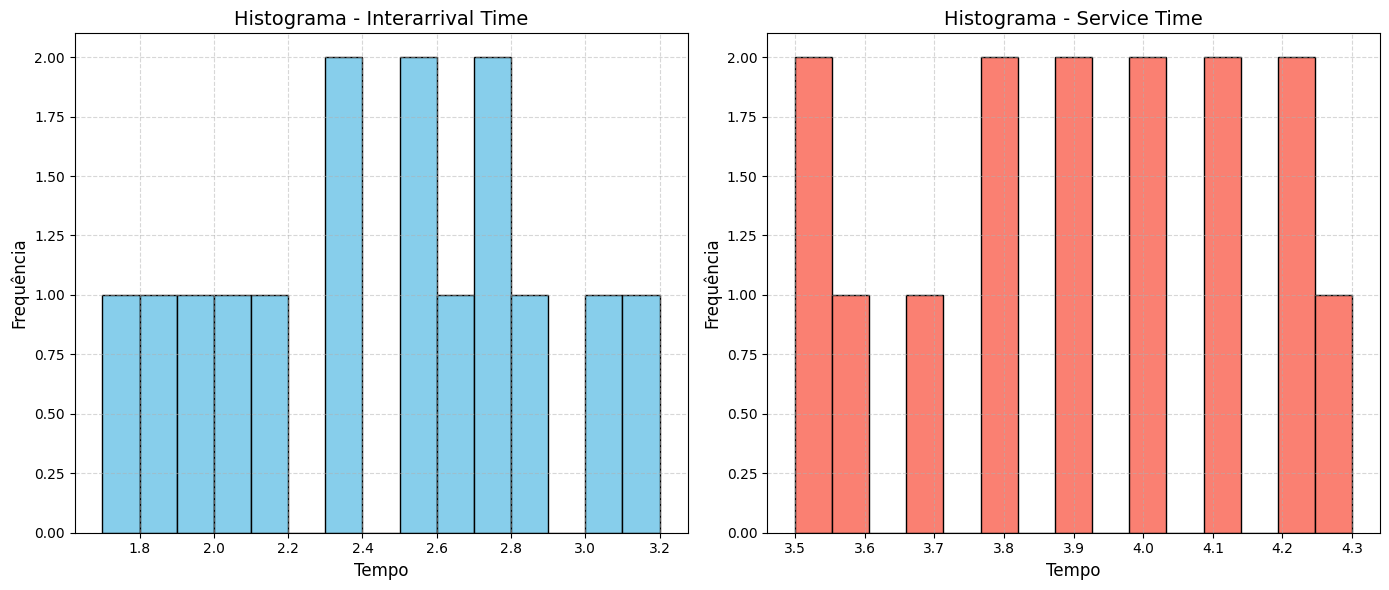

In [24]:
# Remove linhas com valores ausentes
df = df.dropna()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(df["interarrival_time"], bins=df["interarrival_time"].count(), color='skyblue', edgecolor='black')
plt.title("Histograma - Interarrival Time", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(df["service_time"], bins=df["service_time"].count(), color='salmon', edgecolor='black')
plt.title("Histograma - Service Time", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2.2 Boxplot Comparativo

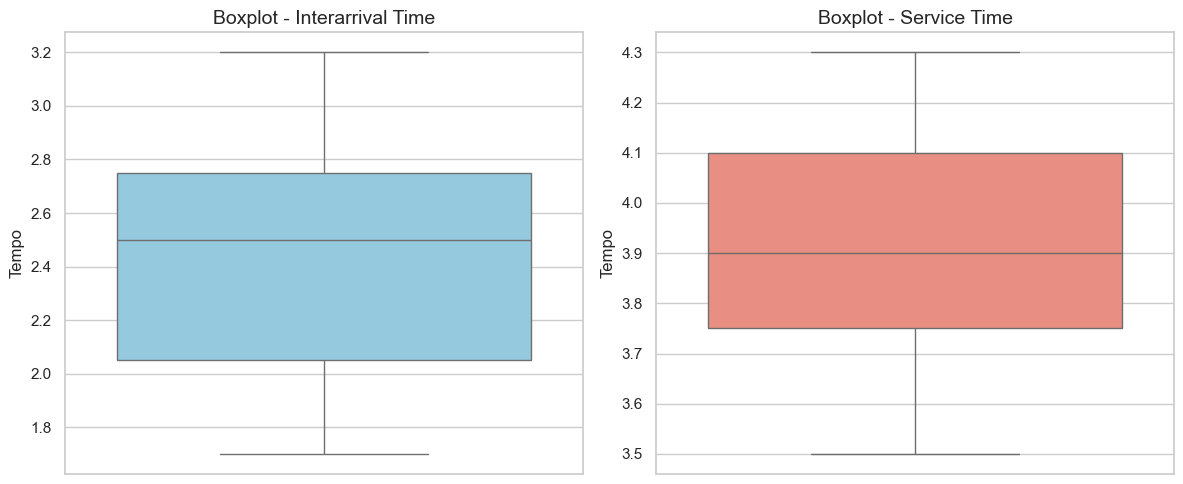

In [25]:

# Remove valores ausentes, se houver
df = df.dropna()

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# Boxplot para interarrival_time
plt.subplot(1, 2, 1)
sns.boxplot(y=df["interarrival_time"], color='skyblue')
plt.title("Boxplot - Interarrival Time", fontsize=14)
plt.ylabel("Tempo", fontsize=12)

# Boxplot para service_time
plt.subplot(1, 2, 2)
sns.boxplot(y=df["service_time"], color='salmon')
plt.title("Boxplot - Service Time", fontsize=14)
plt.ylabel("Tempo", fontsize=12)

plt.tight_layout()
plt.show()

# 3. Intervalos de Confiança

Vamos calcular os intervalos de confiança para as médias dos tempos de atendimento e entre chegadas.

In [16]:
def calcular_ic(dados, confianca):
    media = np.mean(dados)
    n = len(dados)
    std_erro = stats.sem(dados)
    ic = stats.t.interval(confianca, n-1, media, std_erro)
    return ic

niveis_confianca = [0.90, 0.95, 0.99]

print(f'Intervalos de Confiança para Tempo de Atendimento:')
for nivel in niveis_confianca:
    ic = calcular_ic(df['service_time'], nivel)
    print(f'IC {nivel*100}%: [{ic[0]:.2f}, {ic[1]:.2f}]')

print(f'Intervalos de Confiança para Tempo entre Chegadas:')
for nivel in niveis_confianca:
    ic = calcular_ic(df['interarrival_time'], nivel)
    print(f'IC {nivel*100}%: [{ic[0]:.2f}, {ic[1]:.2f}]')


Intervalos de Confiança para Tempo de Atendimento:
IC 90.0%: [3.79, 4.02]
IC 95.0%: [3.77, 4.05]
IC 99.0%: [3.71, 4.10]
Intervalos de Confiança para Tempo entre Chegadas:
IC 90.0%: [2.22, 2.63]
IC 95.0%: [2.17, 2.68]
IC 99.0%: [2.08, 2.78]
